In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Assignment'
image_folder = os.path.join(base_path, 'flash_images', 'flash_images')
train_csv_path = os.path.join(base_path, 'train_corners.csv')

df = pd.read_csv(train_csv_path)
print(f"Total images in training set: {len(df)}")
df.head()

Mounted at /content/drive
Total images in training set: 6458


,filename,corners,check_corners
0,A0044N12_Flash0_A0044N12fullhd_1632909983146_2...,596.57 490.22 244.38 487.29 241.78 276.59 597....,1
1,A0044N1N_Flash0_A0044N1Nfullhd_1632984711470_2...,435.37 389.02 176.33 388.07 178.51 231.85 435....,1
2,G00002EEE_Flash0_G00002EEEfullhd_1632736086759...,619.95 503.83 242.01 515.24 237.94 284.02 615....,1
3,A0044MX6_Flash0_A0044MX6fullhd_1632897545539_2...,461.47 378.02 190.49 379.34 190.8 216.03 460.6...,1
4,A0044N2K_Flash0_A0044N2Kfullhd_1632742668466_2...,601.63 520.85 217.51 508.31 214.39 272.79 596....,1


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_tag_corners_robust(image_path, min_area=5000):
    img = cv2.imread(image_path)
    if img is None:
        return None, None, None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    #  Fix uneven lighting with CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_gray = clahe.apply(gray)

    blurred = cv2.GaussianBlur(enhanced_gray, (5, 5), 0)

    v = np.median(blurred)
    sigma = 0.33
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    edged = cv2.Canny(blurred, lower, upper)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
    closed_edges = cv2.morphologyEx(edged, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(closed_edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

    detected_corners = None

    for c in contours:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.03 * peri, True)

        if len(approx) == 4:
            area = cv2.contourArea(approx)
            if area > min_area:
                detected_corners = approx.reshape(4, 2)
                break

    return img, closed_edges, detected_corners

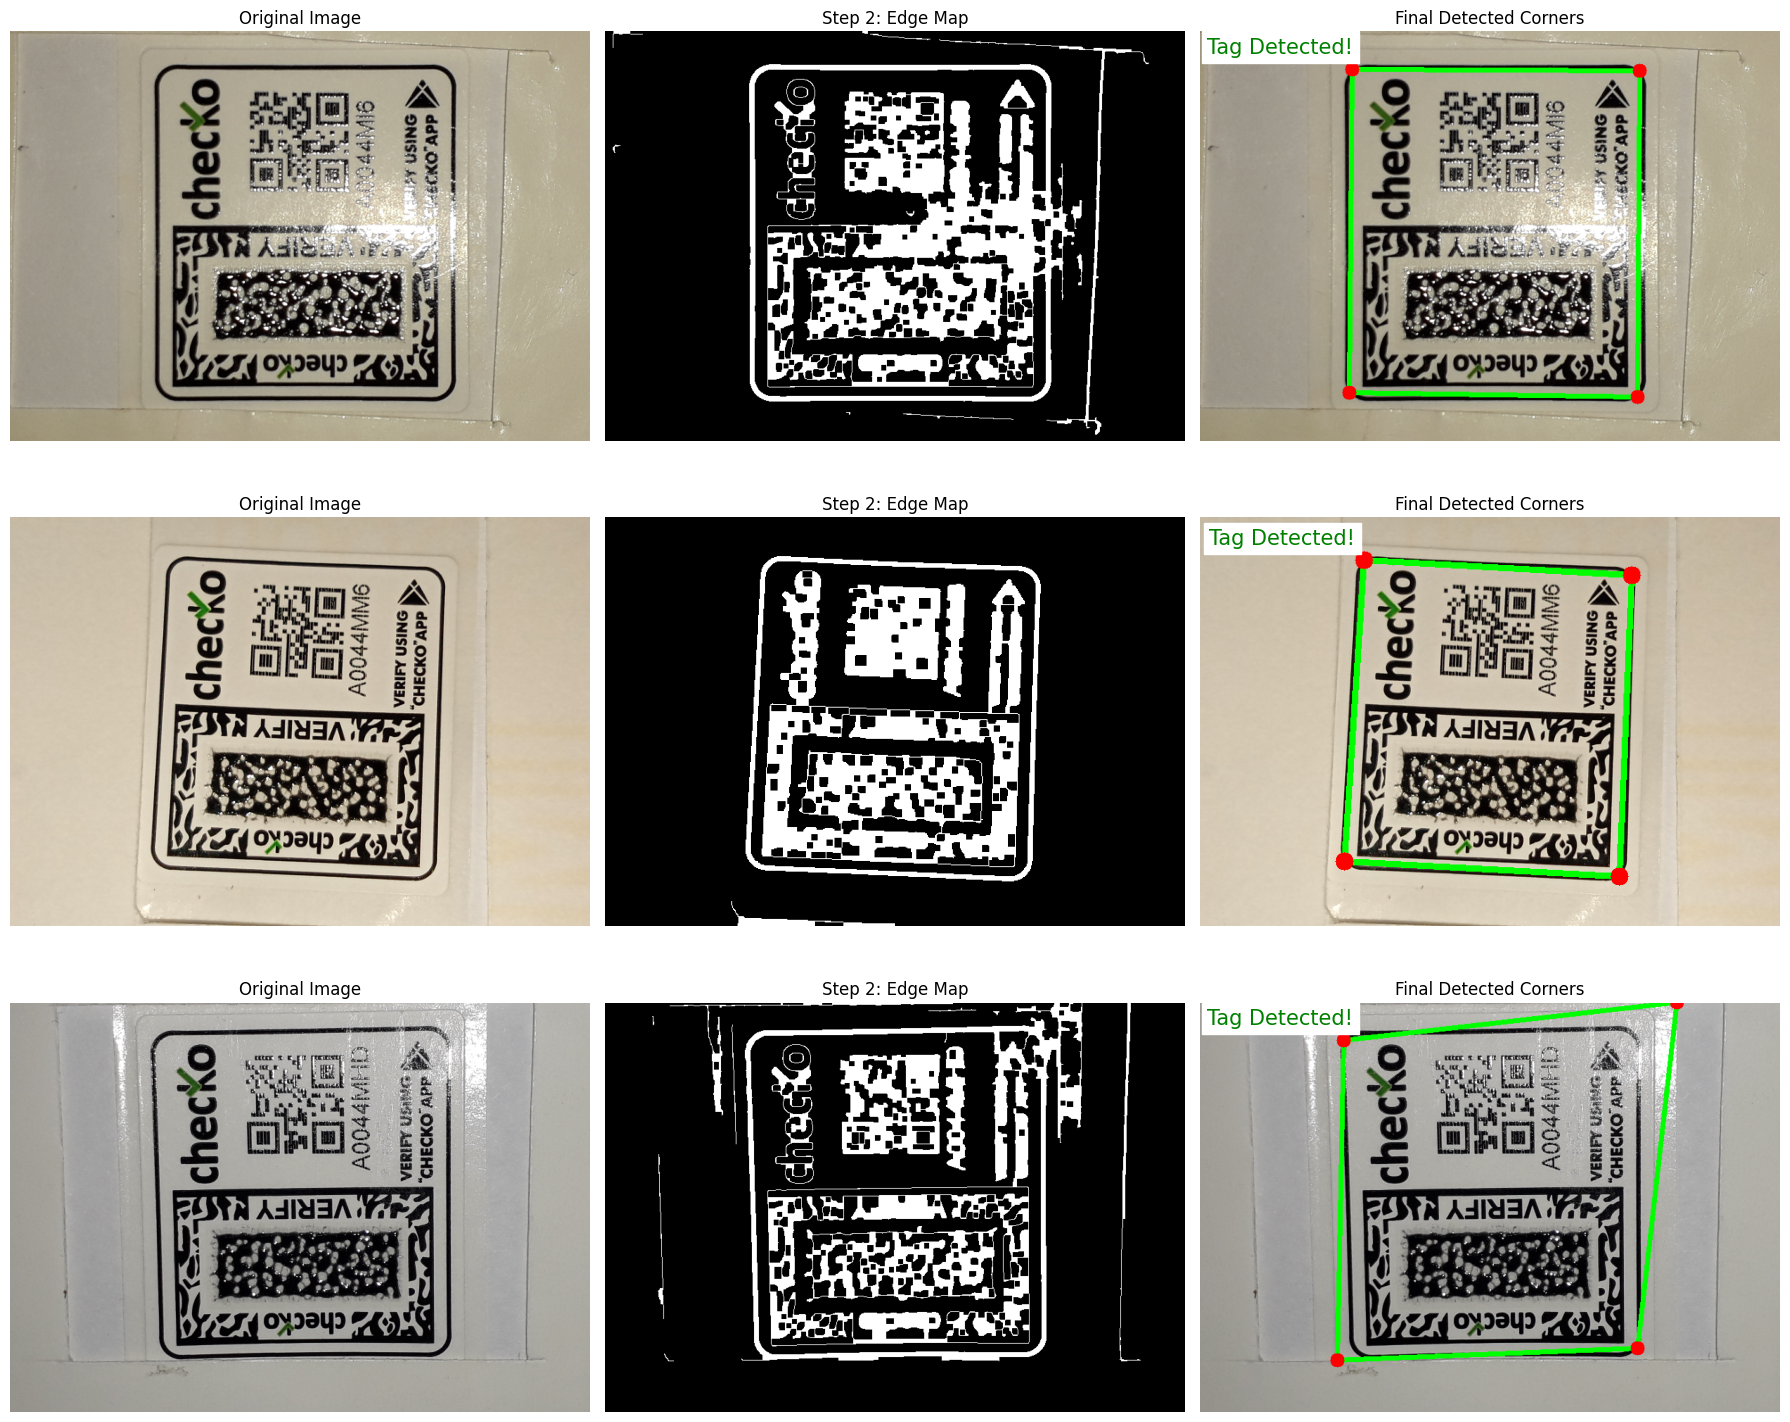

In [4]:
sample_images = df[df['check_corners'] == 1].sample(3)['filename'].values

plt.figure(figsize=(18, 15))

for i, filename in enumerate(sample_images):
    img_path = os.path.join(image_folder, filename)

    original_img, edge_map, corners = detect_tag_corners_robust(img_path)

    if original_img is None:
        continue

    original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i*3 + 1)
    plt.title("Original Image")
    plt.imshow(original_rgb)
    plt.axis("off")

    plt.subplot(3, 3, i*3 + 2)
    plt.title("Step 2: Edge Map")
    plt.imshow(edge_map, cmap='gray')
    plt.axis("off")

    plt.subplot(3, 3, i*3 + 3)
    plt.title("Final Detected Corners")
    img_with_corners = original_rgb.copy()

    if corners is not None:
        cv2.polylines(img_with_corners, [corners], isClosed=True, color=(0, 255, 0), thickness=5)
        for point in corners:
            cv2.circle(img_with_corners, tuple(point), radius=10, color=(255, 0, 0), thickness=-1)
        plt.text(10, 30, "Tag Detected!", color='green', fontsize=15, backgroundcolor='white')
    else:
        plt.text(10, 30, "No Tag Found", color='red', fontsize=15, backgroundcolor='white')

    plt.imshow(img_with_corners)
    plt.axis("off")

plt.tight_layout()
plt.show()